In [1]:
from google.colab import files
uploaded=files.upload()

Saving auto-mpg.csv to auto-mpg.csv


In [2]:
# Dataset Load
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("auto-mpg.csv")
df=pd.DataFrame(data)
print(df.head(10))

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   
5  15.0          8         429.0        198    4341          10.0          70   
6  14.0          8         454.0        220    4354           9.0          70   
7  14.0          8         440.0        215    4312           8.5          70   
8  14.0          8         455.0        225    4425          10.0          70   
9  15.0          8         390.0        190    3850           8.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skyla

In [ ]:
# NULL Value checking
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
# Dataset column name
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [ ]:
# Dataset columns information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [6]:
# Datatype Change
df['horsepower']=pd.to_numeric(df['horsepower'],errors='coerce')

In [7]:
# NULL value filling
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
df['horsepower']=imputer.fit_transform(df[['horsepower']])

In [8]:
# skewness check
df.skew(numeric_only=True)

,0
mpg,0.457066
cylinders,0.526922
displacement,0.719645
horsepower,1.095552
weight,0.531063
acceleration,0.278777
model year,0.011535
origin,0.923776


In [9]:
# Outlier Percentage
cols=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration']
for col in cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  outliers=df[(df[col]<Q1-1.5*IQR) | (df[col]>Q3+1.5*IQR)]
  pct=len(outliers)/len(df)*100
  print(f'{col}: {pct:.2f}%')

mpg: 0.25%
cylinders: 0.00%
displacement: 0.00%
horsepower: 2.76%
weight: 0.00%
acceleration: 1.76%


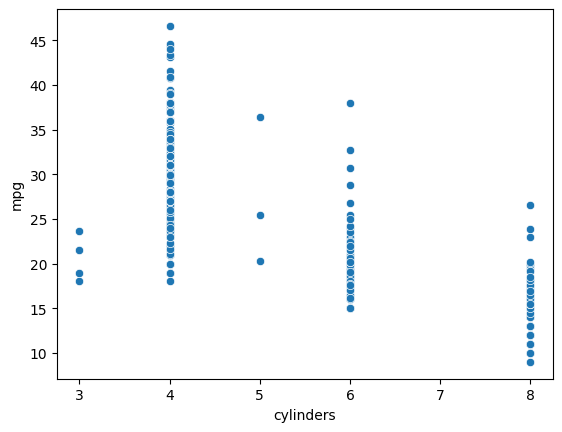

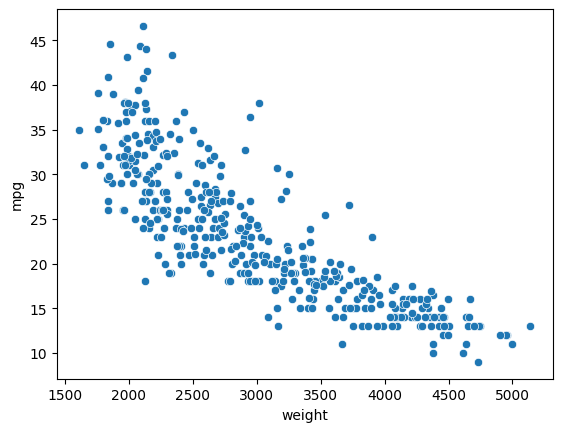

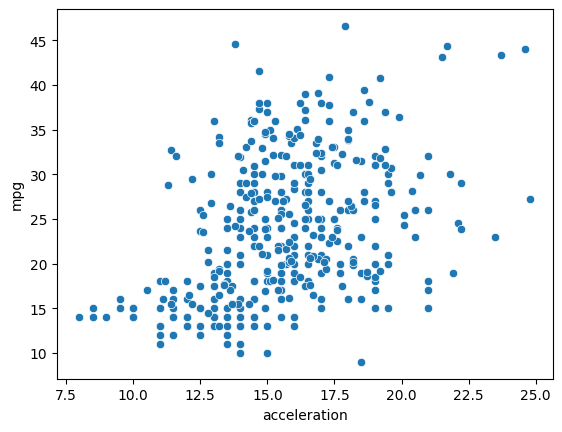

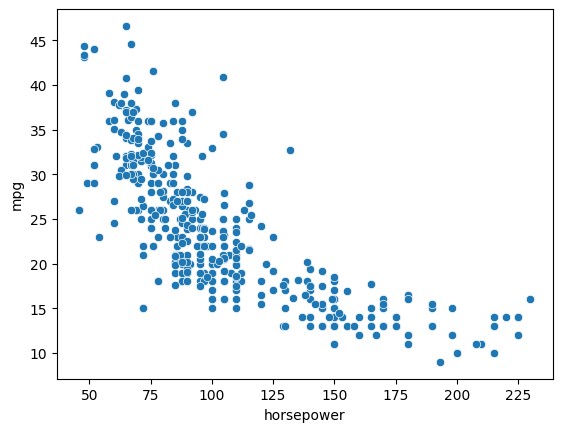

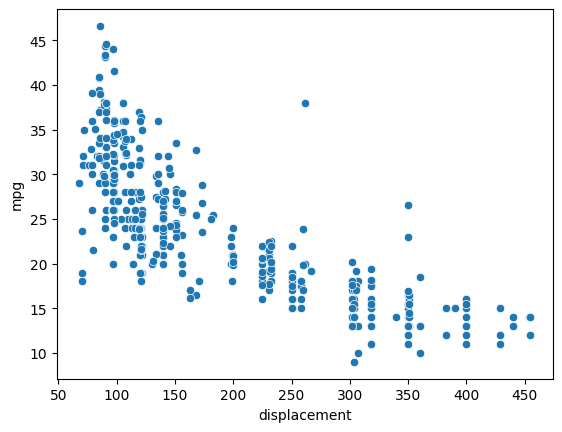

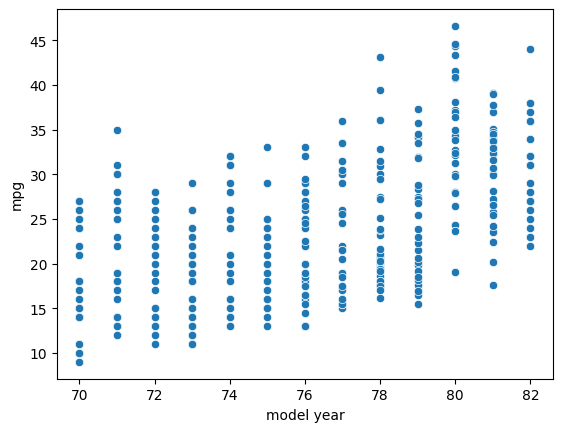

In [10]:
# Plotting
sns.scatterplot(data=df,x="cylinders",y="mpg")
plt.show()
sns.scatterplot(data=df,x="weight",y="mpg")
plt.show()
sns.scatterplot(data=df,x="acceleration",y="mpg")
plt.show()

sns.scatterplot(data=df,x="horsepower",y="mpg")
plt.show()
sns.scatterplot(data=df,x="displacement",y="mpg")
plt.show()
sns.scatterplot(data=df,x="model year",y="mpg")
plt.show()

In [11]:
# correlation check
print(df.corr(numeric_only=True)['mpg'].sort_values(ascending=False))

mpg             1.000000
model year      0.579267
origin          0.563450
acceleration    0.420289
horsepower     -0.771437
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


In [12]:
# x,y selection
features=df[['acceleration','cylinders', 'displacement', 'horsepower', 'weight',
        'model year']]
x=features
y=df['mpg']

In [13]:
# Training, testing & scalling
from sklearn.preprocessing import PolynomialFeatures
pf=PolynomialFeatures(degree=2)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
from  sklearn.model_selection import train_test_split




x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train_poly=pf.fit_transform(x_train)
x_test_poly=pf.transform(x_test)

x_train=ss.fit_transform(x_train_poly)
x_test=ss.transform(x_test_poly)


In [14]:
# Model Selection
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [15]:
# Model Accuracy
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
y_pred=lr.predict(x_test)
print(f"R2 Score (test): {r2_score(y_test,y_pred)*100:.2f}")
print(f"R2 Score (train): {lr.score(x_train,y_train)*100:.2f}%")
print(f"MSE: {mean_squared_error(y_test,y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred)):.2f}")


R2 Score (test): 86.89
R2 Score (train): 88.58%
MSE: 7.05
RMSE: 2.66


In [ ]:
import numpy as np

In [ ]:
# input ,output by user
cy=int(input("Enter cyllinder size:"))
ac=float(input("Enter the accelaration:"))
dis=float(input("Enter the displacement:"))
hp=float(input("Enter the horsepower:"))
wt=float(input("Enter the weight:"))
my=int(input("Enter the model year:"))
imp=np.array([[ac, cy, dis, hp, wt, my]])


imp_poly = pf.transform(imp)


scaled_data = ss.transform(imp_poly)

prediction=lr.predict(scaled_data)
print("Predicted car millage:", prediction)

Enter cyllinder size:4
Enter the accelaration:15
Enter the displacement:140
Enter the horsepower:90
Enter the weight:2500
Enter the model year:82
Predicted car millage: [31.79091461]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


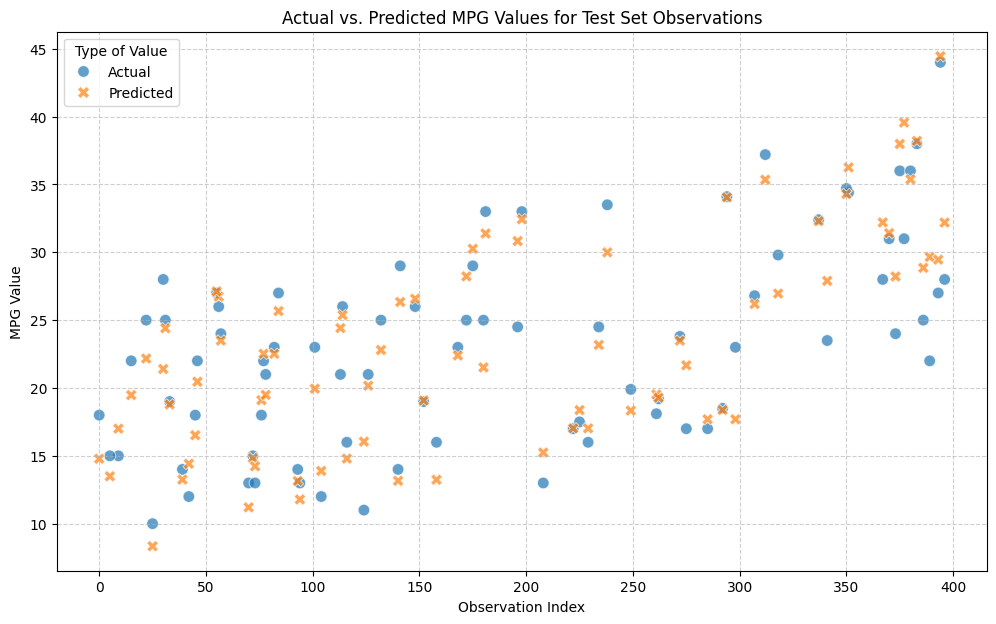

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert y_pred (numpy array) to a Series with the same index as y_test for proper alignment
y_pred_series = pd.Series(y_pred, index=y_test.index)

# Create a DataFrame to combine y_test and y_pred
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_series
})

# Reset index to make it a column for plotting
comparison_df = comparison_df.reset_index().rename(columns={'index': 'Observation_Index'})

# Melt the DataFrame to long format for easy plotting with hue
melted_df = comparison_df.melt(id_vars='Observation_Index', var_name='Value_Type', value_name='MPG')

plt.figure(figsize=(12, 7))
sns.scatterplot(data=melted_df, x='Observation_Index', y='MPG', hue='Value_Type', style='Value_Type', s=70, alpha=0.7)
plt.title('Actual vs. Predicted MPG Values for Test Set Observations')
plt.xlabel('Observation Index')
plt.ylabel('MPG Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Type of Value')
plt.show()